# Setup/Imports

In [10]:
import sys
import os

import torch

sys.path.append(os.path.abspath("../src"))

from models import SimpleCNN, ResNet18, DenseNet121, EfficientNetB0, MobileNetV2, ShuffleNetV2, SqueezeNet

from data import (
    prepare_full_dataframe, 
    prepare_data
 )

from utils import (
    get_device,
    load_experiment_outputs,
    save_experiment_outputs,
    get_experiment_outputs_path
 )

from train import run_training_pipeline, run_smoke_test

from experiement_types import Metrics, History, ModelOutput

import config

In [11]:
import sys
print(f"Python executable: {sys.executable}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Python executable: c:\Users\profb\Projects\cxr-model-benchmark\.venv\Scripts\python.exe
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


# Data Preprocessing

In [3]:
dataset_path = config.DATASET_PATH
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())
df["Finding Labels"].value_counts().head()

Dataset location: D:\Datasets\NIH_Chest_X-Rays
Total images: 112120
Unique patients: 30805


Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [4]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [5]:
train_loader, val_loader, test_loader = prepare_data(df)
device = get_device()

Using CUDA (GPU)


# Model Individual Training/Testing

In [6]:
model_registry = {
    "SimpleCNN": SimpleCNN,
    "ResNet18": lambda: ResNet18(num_classes=2, in_channels=1),
    "DenseNet121": lambda: DenseNet121(num_classes=2, in_channels=1),
    "EfficientNet-B0": lambda: EfficientNetB0(num_classes=2, in_channels=1),
    "MobileNetV2": lambda: MobileNetV2(num_classes=2, in_channels=1),
    "ShuffleNetV2": lambda: ShuffleNetV2(num_classes=2, in_channels=1),
    "SqueezeNet": lambda: SqueezeNet(num_classes=2, in_channels=1)
}
model_names = list(model_registry.keys())
model_builders = list(model_registry.values())

experiment_outputs_path = get_experiment_outputs_path()
experiment_outputs = load_experiment_outputs(experiment_outputs_path)
print(f"Loaded {len(experiment_outputs)} saved result(s) from {experiment_outputs_path}")

def train_and_store_model(index, live_plot=True):
    metrics, history = run_training_pipeline(
        model_names[index],
        model_builders[index],
        train_loader,
        val_loader,
        test_loader,
        device,
        live_plot=live_plot,
    )
    experiment_outputs[model_names[index]] = ModelOutput(
        metrics=Metrics(**metrics),
        history=History(**history),
    )
    save_experiment_outputs(experiment_outputs, experiment_outputs_path)
    print(f"Saved {model_names[index]} results to {experiment_outputs_path}")
    return experiment_outputs[model_names[index]]

Loaded 4 saved result(s) from c:\Users\profb\Projects\cxr-model-benchmark\outputs\experiment_outputs\experiment_outputs.json


## Simple CNN

### Smoke Test

In [7]:
run_smoke_test(
    model_name=model_names[0],
    model_builder=model_builders[0],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[0]}-SMOKE",
)


=== Smoke test: SimpleCNN (epochs=1, patience=1) ===

=== Training SimpleCNN ===


Epoch 1/1 | ETA (Remaining): 00:00:00 | Total ETA: 00:06:44
  Train Loss: 0.6500 | Train Acc: 0.6291
  Val Loss: 0.6372 | Val Acc: 0.6505
  Val Precision: 0.6322
  Val Recall: 0.5590 | Val F1: 0.5933
  Val AUPRC: 0.6304
  LR: 0.0003
------------------------------------------------------------
Saved best model to c:\Users\profb\Projects\cxr-model-benchmark\outputs\models\best_simplecnn.pt
------------------------------------------------------------


Smoke test persistence verified for 'SimpleCNN-SMOKE' at c:\Users\profb\Projects\cxr-model-benchmark\outputs\experiment_outputs\experiment_outputs.json


({'model': 'SimpleCNN',
  'epochs': 1,
  'batch_size': 64,
  'image_size': 224,
  'test_loss': 0.6325829863372885,
  'accuracy': 0.6499509563511525,
  'precision': 0.6408201017419455,
  'recall': 0.5515457078413162,
  'f1': 0.5928408442669709,
  'auprc': 0.6551020171347021},
 {'train_loss': [0.6500111131184573],
  'train_acc': [0.6291331998885145],
  'val_loss': [0.6371549383023063],
  'val_acc': [0.6505274386630319],
  'val_precision': [0.6321822189566495],
  'val_recall': [0.558991683991684],
  'val_f1': [0.5933383904558306],
  'val_auprc': [0.6304073122598851],
  'lr': [0.0003],
  'lr_backbone': [],
  'lr_head': [],
  'backbone_frozen': [False],
  'best_epoch': 1})

### Training

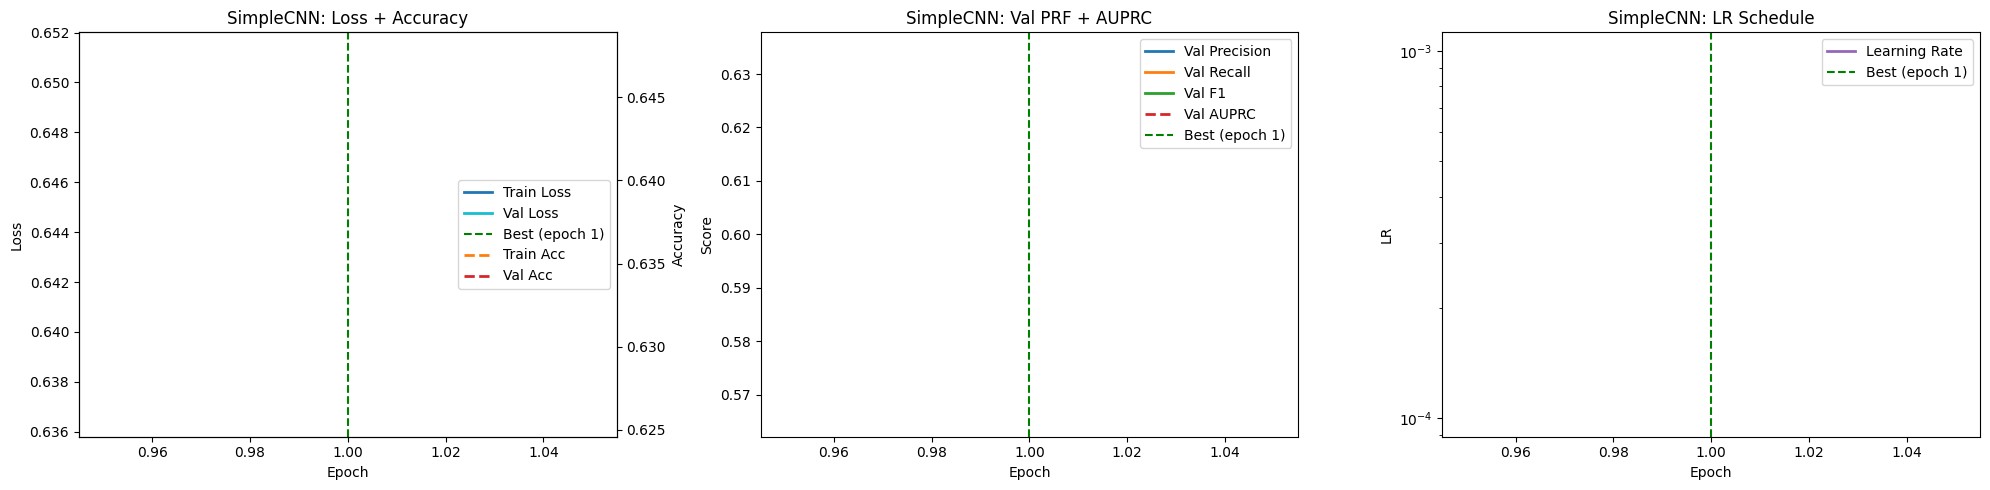

KeyboardInterrupt: 

In [8]:
train_and_store_model(0, live_plot=True)

## ResNet-18

### Smoke Test

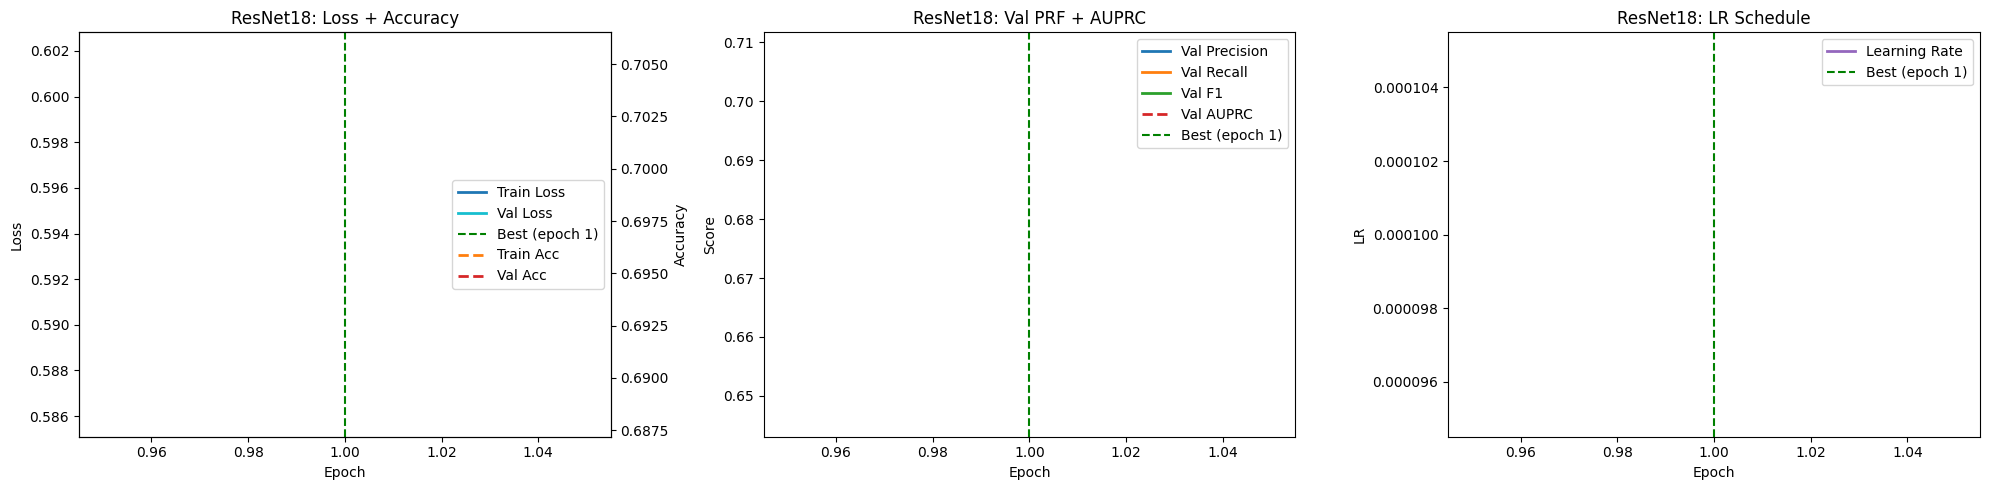

Val:   0%|          | 0/255 [00:11<?, ?it/s]

Smoke test persistence verified for 'ResNet18-SMOKE' at c:\Users\profb\Projects\cxr-model-benchmark\outputs\experiment_outputs\experiment_outputs.json


({'model': 'ResNet18',
  'epochs': 1,
  'batch_size': 64,
  'image_size': 224,
  'test_loss': 0.579186604705846,
  'accuracy': 0.7140755272192251,
  'precision': 0.6963236299029657,
  'recall': 0.6759984078545841,
  'f1': 0.6860105022216239,
  'auprc': 0.7092894319274845},
 {'train_loss': [0.6020104047446665],
  'train_acc': [0.6880685129348569],
  'val_loss': [0.5859009554505673],
  'val_acc': [0.7056418158113074],
  'val_precision': [0.6863307387682643],
  'val_recall': [0.6530665280665281],
  'val_f1': [0.6692855716092949],
  'val_auprc': [0.7016991098444094],
  'lr': [0.0001],
  'best_epoch': 1})

In [ ]:
run_smoke_test(
    model_name=model_names[1],
    model_builder=model_builders[1],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[1]}-SMOKE",
)

### Training

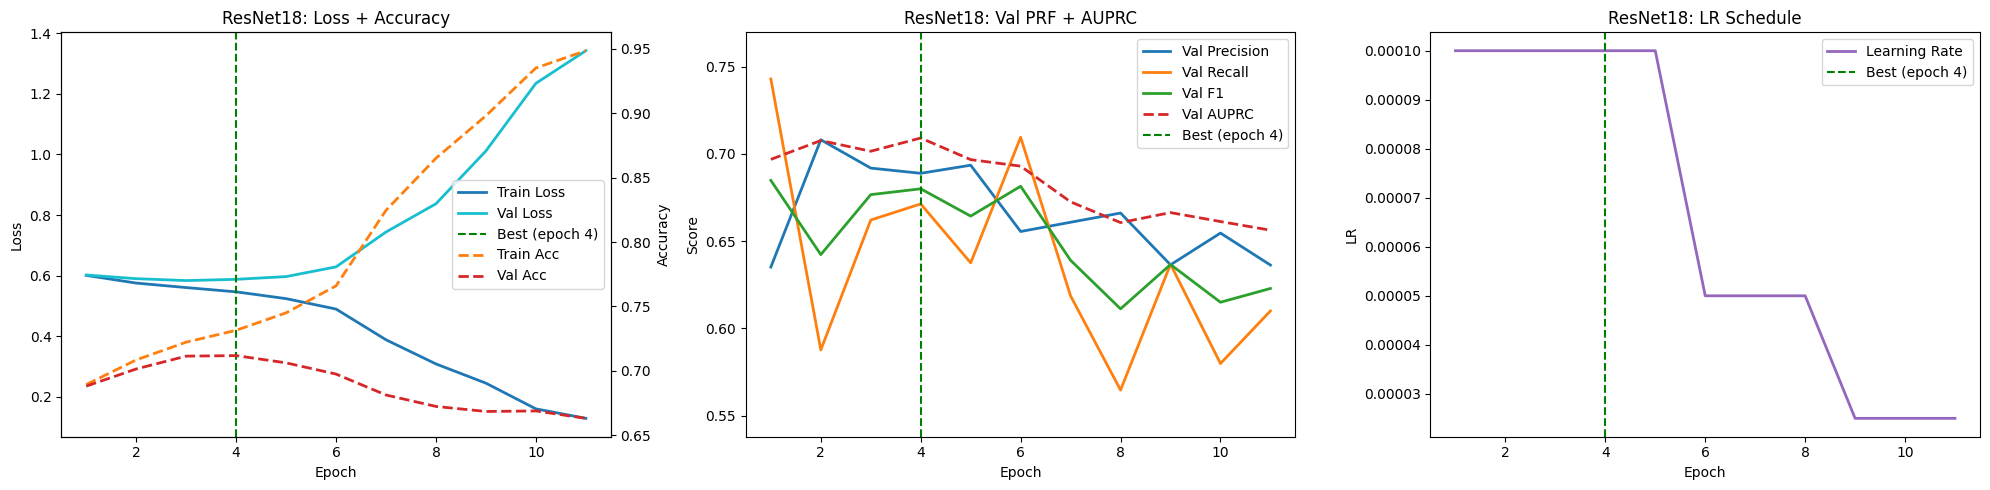

Early stopping at epoch 11 (patience 7 exceeded)


Val:   0%|          | 0/255 [00:12<?, ?it/s]

Saved ResNet18 results to c:\Users\profb\Projects\cxr-model-benchmark\outputs\experiment_outputs\experiment_outputs.json


ModelOutput(metrics=Metrics(model='ResNet18', epochs=11, batch_size=64, image_size=224, test_loss=0.5839730690892506, accuracy=0.7121137812653261, precision=0.6887707641196014, recall=0.6876741409048693, f1=0.6882220156685699, auprc=0.7148086964602383), history=History(train_loss=[0.6009403460472879, 0.5754549806665685, 0.5606512156589281, 0.5465292527648323, 0.5241237623161102, 0.4897065387019956, 0.388311456752143, 0.30852668840216974, 0.24503520198845413, 0.16021707344475627, 0.12890863751700304], train_acc=[0.689386069374414, 0.7085159753718296, 0.7222996427395039, 0.7315098690044848, 0.7450781665695391, 0.7660323814832645, 0.8247143182912307, 0.8651278283122609, 0.8981047457369448, 0.9352243646590823, 0.9486152988572731], val_loss=[0.6021043404988009, 0.5899716792011114, 0.583761306810509, 0.5878774119353173, 0.5968787814396117, 0.6290136412787497, 0.744078000278231, 0.8373282089523898, 1.0117534511643478, 1.2349405780114933, 1.342624699559358], val_acc=[0.6881592983287899, 0.7014

In [ ]:
train_and_store_model(1, live_plot=True)

## DenseNet-121

### Smoke Test

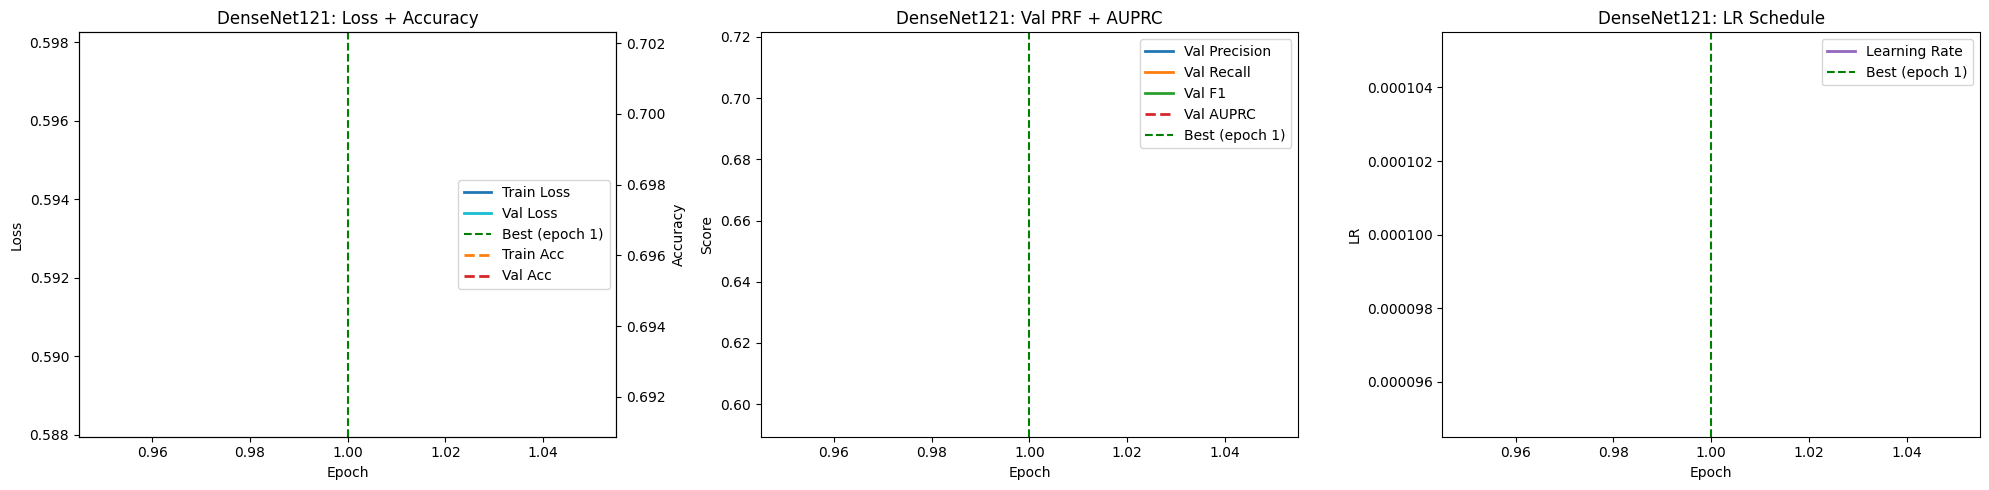

Val:   0%|          | 0/255 [00:12<?, ?it/s]

Smoke test persistence verified for 'DenseNet121-SMOKE' at c:\Users\profb\Projects\cxr-model-benchmark\outputs\experiment_outputs\experiment_outputs.json


({'model': 'DenseNet121',
  'epochs': 1,
  'batch_size': 64,
  'image_size': 224,
  'test_loss': 0.5834857832280487,
  'accuracy': 0.7107650809220206,
  'precision': 0.7132052639540161,
  'recall': 0.6255804696828977,
  'f1': 0.6665253039298841,
  'auprc': 0.7067347756955404},
 {'train_loss': [0.5977833293967157],
  'train_acc': [0.6913877416575873],
  'val_loss': [0.5884208339176514],
  'val_acc': [0.7017897356880408],
  'val_precision': [0.7005420054200542],
  'val_recall': [0.6045997920997921],
  'val_f1': [0.6490444971404659],
  'val_auprc': [0.706239687620987],
  'lr': [0.0001],
  'best_epoch': 1})

In [ ]:
run_smoke_test(
    model_name=model_names[2],
    model_builder=model_builders[2],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[2]}-SMOKE",
)

### Training

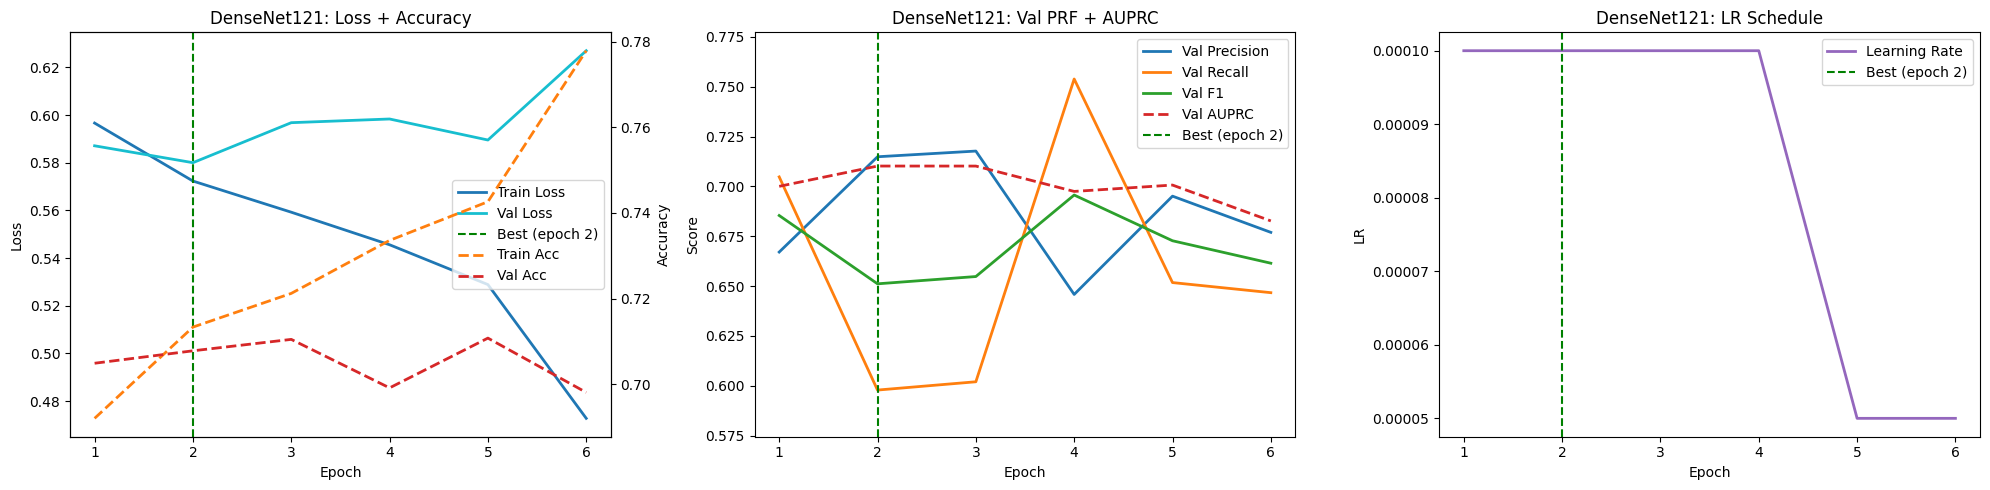

Train Epoch 7:   0%|          | 0/1234 [00:12<?, ?it/s]

In [ ]:
train_and_store_model(2, live_plot=True)

## EfficientNet-B0

### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[3],
    model_builder=model_builders[3],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[3]}-SMOKE",
)

### Training

In [ ]:
train_and_store_model(3, live_plot=True)

## MobileNet-V2

### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[4],
    model_builder=model_builders[4],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[4]}-SMOKE",
)

### Training

In [ ]:
train_and_store_model(4, live_plot=True)

## ShuffleNetV2

### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[5],
    model_builder=model_builders[5],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[5]}-SMOKE",
)

### Training

In [ ]:
train_and_store_model(5, live_plot=True)

## SqueezeNet

### Smoke Test

In [ ]:
run_smoke_test(
    model_name=model_names[6],
    model_builder=model_builders[6],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
    persist_outputs=True,
    persist_model_name=f"{model_names[6]}-SMOKE",
)

### Training

In [ ]:
train_and_store_model(6, live_plot=True)

# Model Comparison Plots
Visualize the test results for all models using bar plots for accuracy, precision, recall, and F1 score.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

experiment_outputs = load_experiment_outputs(experiment_outputs_path)
if not experiment_outputs:
    raise ValueError(
        f"No saved experiment outputs found at {experiment_outputs_path}. Run at least one training cell first."
    )

results_df = pd.DataFrame([
    vars(out.metrics) for out in experiment_outputs.values()
])

metrics = ["accuracy", "precision", "recall", "f1", "auprc"]

plt.figure(figsize=(12, 6))
results_melted = results_df.melt(
    id_vars="model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
 )
sns.barplot(data=results_melted, x="model", y="Score", hue="Metric")
plt.title("Model Comparison on Test Set")
plt.ylabel("Score")

min_score = results_melted["Score"].min()
max_score = results_melted["Score"].max()
padding = max(0.01, 0.08 * (max_score - min_score))
ymin = max(0.0, min_score - padding)
ymax = min(1.0, max_score + padding)
plt.ylim(ymin, ymax)

plt.legend(loc="lower right")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()